# Pokemon Center Plushies Analysis

### 0.0 Summary Points 

- Comfy Friends and Squishmallows have the highest positive impressions (i.e. highest 5 star ratings with the lowest number of 1 star ratings)
- Ditto Friends have the lowest number of impressions (i.e. lowest number of 5 stars with one of the highest number of 1 stars)

### 1.0 Data Cleaning / Preparation

As the Data was gathered manually through observation, the data is complete hence no missing data to be handled and it has been double checked with each entry. If you would like access to the data, please reach out via LinkedIn: [Erjill De Vera](https://www.linkedin.com/in/erjill-de-vera-228823189/)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plushies_data = pd.read_excel("PokemonCentreUK.xlsx")
plushies_data.head() # Sample of the Data

,Primary Key,Item Name,Country of Origin,Width (cm),Length (cm),Height (cm),Plush Category,Price,Pokemon,Region,5 Star Review,4 Star Review,3 Star Review,2 Star Review,1 Star Review,Most Recent Date Review,Recorded Date
0,1,Ditto As Jolteon Plush,Philippines,8.4,10.2,16.5,Ditto,16.99,Jolteon,Kanto,3,0,0,0,0,2025-05-25,2025-07-04
1,2,Ditto As Glaceon Plush,Philippines,11.4,15.2,20.3,Ditto,16.99,Glaceon,Sinnoh,4,1,0,0,0,2025-06-17,2025-07-04
2,3,Ditto As Eevee Plush,Philippines,8.4,14.0,17.3,Ditto,16.99,Eevee,Kanto,7,1,0,0,0,2025-06-13,2025-07-04
3,4,Ditto As Vaporeon Plush,Philippines,8.4,11.4,16.5,Ditto,16.99,Vaporeon,Kanto,5,4,0,0,0,2025-06-17,2025-07-07
4,5,Ditto As Flareon Plush,Philippines,8.4,14.0,16.5,Ditto,16.99,Flareon,Kanto,3,0,0,0,0,2025-06-15,2025-07-07


In [4]:
##Convert the Ratings review into integers instead of floats:
ratings_index = [10,11,12,13,14]
plushies_data.iloc[:, ratings_index] = plushies_data.iloc[:, ratings_index].astype(int)

### 2.0 Data Exploration


#### 2.1 Analysis of which Plush Category has a highest overall ratings

The first thing to explore is the Plush Category, which of the Pokemon Plushies line up provided in the Pokemon Centre UL's website has the highest average 5 star rating. The main findings in this visualisation include:

**Top 2 categories for 5 star reviews:**
- Comfy Friends (188 average)
- Squishmallow Plushes (76 average) are the highest

**Bottom 2 categories for 5 star reviews:**
- Key Chain (12 average)
- Ditto Plush lowest (10 average) are the lowest

The plushies have less than 0 average for their 1 star rating, which is a great sign. There is not too much of a difference between them. However, we can still analyse which plushy category is more probable to recieve a 1 star rating:
**Highest categories for 1 star reviews:**
-  Sitting Cuties       0.148148
-  Spring Plush       0.142857
-  Ditto       0.100000
  
And that Comfy Friends, Dolls Plush, Key Chain Plush, Large Plush, Squishmallows Plush have an average of 0 1 star reviews.

**Conclusions we can make**
- Comfy Friends and Squish mallow plushies have the highest positive impressions (i.e. highest number of 5 stars, with the lowest number of 1 stars)
- Ditto plushies have the highest negative impressions (i.e. lowest number of 5 stars, with the one of the highest probable 1 stars)


In [30]:
def rating_Comparison(category, rating, title):
    """
    Creates a bar chart showing the average rating for each category.

    Parameters:
        category (str): The column used to group the data.
        rating (str): The column containing the rating values.
        title (str): The title displayed on the chart.

    Returns:
        None: Displays the bar chart.
    """

    averages = plushies_data.groupby(category)[rating].mean().sort_values(ascending=False)
    averages_df = averages.reset_index()
    averages_df.columns = [category, rating]
    print(averages_df)

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=averages_df,
        x=category,
        y=rating,
        order=averages_df[category],
        palette="Set1",
        hue=category,
        legend=False
    )

    plt.title(title)
    plt.xticks(rotation=90)
    plt.ylabel("Average")
    plt.show()

        Plush Category  5 Star Review
0        Comfy Friends     118.052632
1  Squishmallows Plush      76.764706
2          Large Plush      38.190476
3         Dreams Plush      34.916667
4          Dolls Plush      33.866667
5       Sitting Cuties      32.185185
6         Spring Plush      20.285714
7      Key Chain Plush      12.051724
8                Ditto      10.250000


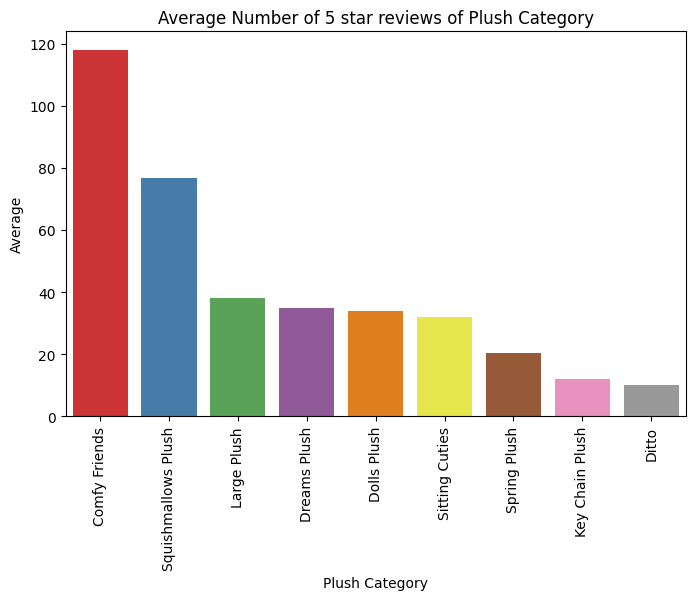

In [ ]:
#Rating of which Plush category has the highest number of 5 star reviews
# Findings include: Comfy Friends (188 average) and Squishmallow Plushes (76 average) are the highest, while Key Chain (12 average) and Ditto Plush lowest (10 average).
rating_Comparison("Plush Category", "5 Star Review", "Average Number of 5 star reviews of Plush Category")

        Plush Category  1 Star Review
0       Sitting Cuties       0.148148
1         Spring Plush       0.142857
2                Ditto       0.100000
3         Dreams Plush       0.083333
4        Comfy Friends       0.000000
5          Dolls Plush       0.000000
6      Key Chain Plush       0.000000
7          Large Plush       0.000000
8  Squishmallows Plush       0.000000


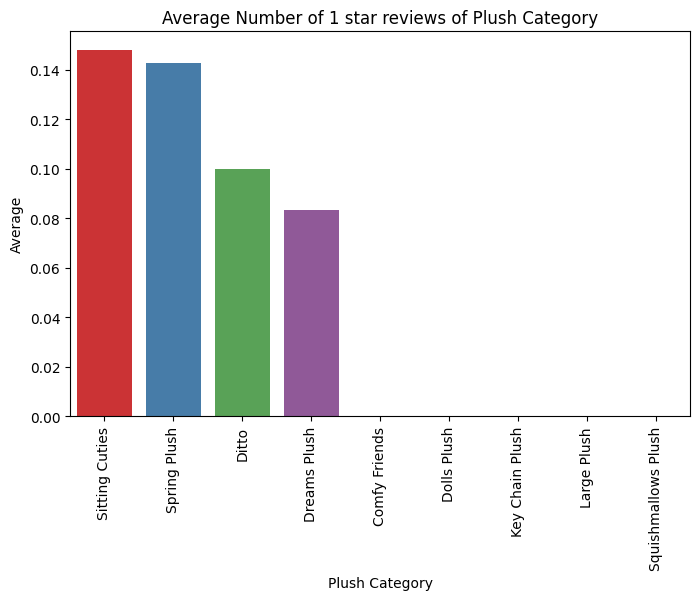

In [ ]:
#Rating of which Plush category has the highest number of 1 star reviews
# Findings include: Comfy Friends (188 average) and Squishmallow Plushes (76 average) are the highest, while Key Chain (12 average) and Ditto Plush lowest (10 average).
rating_Comparison("Plush Category", "1 Star Review", "Average Number of 1 star reviews of Plush Category")

#Here we see that on average is 0, which shows that the product is rarely gets 1 star reviews. 
#Regardless, we see Sitting Cuties, Spring Plush and Ditto are the top 3 which has the highest probable 1 star review.

#Analysis of both 5 star and 1 star review, we can conclude that the Ditto category is the category with the poor ratings (i.e. low 5 star ratings and quite high 1 star rating. )

### 2.2 Which Pokemon Region has the highest ratings?

Our findings show:
- Hisuian (211 average), Jhoto (122 average) and Sinnoh (average) are the top three Regions with the strongest impressions. But Hisuian is double Jhoto's positive 5 star reviews.
- Kanto (0.8 average), Paldea (0.8 average), Jhoto (0.4 average) are the top three regions with the poorest impressions. 

In conclusion:
- Hisuian is the most popular region (highest number of average ratings with lowest number of 1 star review)
- Paldea has one of the lowest popular impression (bottom three 5 star ratings and highest number of 1 star review)

     Region  5 Star Review
0   Hisuian     211.000000
1     Jhoto     122.000000
2    Sinnoh      67.900000
3     Kanto      42.805970
4     Galar      36.083333
5     Hoenn      29.333333
6     Unova      24.615385
7     Johto      24.416667
8    Paldea      22.583333
9     Kalos      20.320000
10    Alola      12.500000


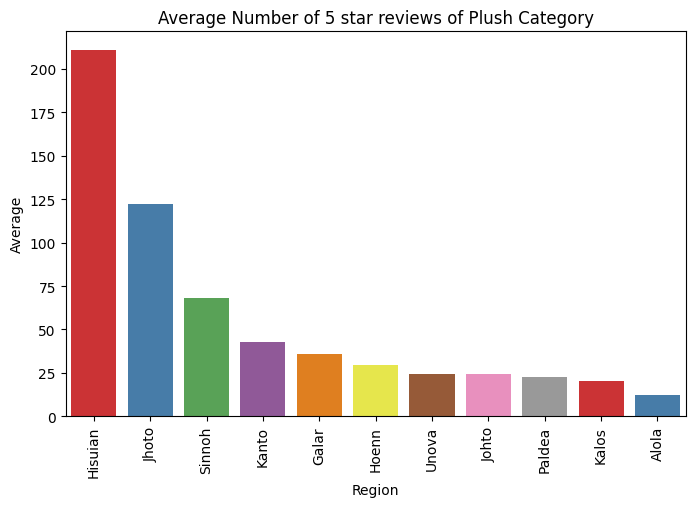

In [35]:
rating_Comparison("Region", "5 Star Review", "Average Number of 5 star reviews of Plush Category")

     Region  1 Star Review
0     Kanto       0.089552
1    Paldea       0.083333
2     Johto       0.041667
3     Alola       0.000000
4     Galar       0.000000
5   Hisuian       0.000000
6     Hoenn       0.000000
7     Jhoto       0.000000
8     Kalos       0.000000
9    Sinnoh       0.000000
10    Unova       0.000000


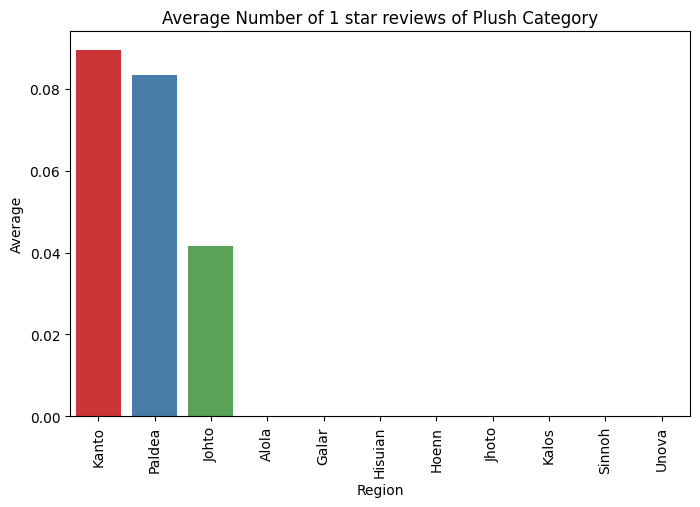

In [36]:
rating_Comparison("Region", "1 Star Review", "Average Number of 1 star reviews of Plush Category")